# Ploting MESH input data

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import netCDF4 as nc
import matplotlib.colors as mcolors
import math
import os

## Function for Ploting for MESH input data (shape file, and MESH_drainage_database.nc)

In [2]:
def plt_var_from_vector_ddb_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    ddbnetcdf_path, 
    variable_name,
    save_path='plot.png',
    text_location=(0.05, 0.95), 
    font_size=10,
    cmap='viridis',  # Set the default colormap to 'viridis'
    cbar_location=[0.96, 0.15, 0.02, 0.7],  # Set default colorbar location
    subplot_adjustments=None  # Optional: Custom subplot adjustments
):
    """
    Plots a specified variable from a NetCDF file, with support for variables
    dependent only on subbasin or on both subbasin and NGRU.

    Parameters:
    - output_basin_path (str): Path to the shapefile containing the basin data.
    - ddbnetcdf_path (str): Path to the NetCDF file containing the data.
    - variable_name (str): Name of the variable to plot from the NetCDF file.
    - save_path (str): File path where the plot will be saved. Defaults to 'plot.png'.
    - text_location (tuple): Tuple specifying the x and y location of the percentage text in each subplot. Defaults to (0.55, 0.95).
    - font_size (int): Font size for the titles and percentage text. Defaults to 10.
    - cmap (str or Colormap): Colormap to use for plotting. Defaults to 'viridis'.
    - cbar_location (list): List specifying the colorbar location [left, bottom, width, height]. Defaults to [0.96, 0.15, 0.02, 0.7].
    - subplot_adjustments (dict): Optional adjustments for subplots. Should be a dictionary with keys such as 'left', 'right', 'bottom', 'top', 'wspace', 'hspace'.

    Returns:
    - None: The function saves the plot to the specified path.

    Usage:
    ```
    output_basin_path = '/path/to/basin/shapefile.shp'
    ddbnetcdf_path = '/path/to/drainage_database.nc'
    variable_name = 'DA'  # or any other variable in the NetCDF file
    save_path = '/path/to/save/plot.png'

    plt_var_from_vector_ddb_netcdf(
        output_basin_path, 
        ddbnetcdf_path, 
        variable_name, 
        save_path,
        text_location=(0.55, 0.95),
        font_size=12,
        cmap='viridis',  # You can specify a different colormap here if needed
        cbar_location=[0.96, 0.15, 0.02, 0.7],  # Custom colorbar location if needed
        subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.2, 'hspace': 0.2}  # Optional subplot adjustments
    )
    ```
    """
    
    # Load and dissolve the shapefile to get a single boundary
    sub_agg_gdf = gpd.read_file(output_basin_path).to_crs(epsg=4326)
    # dissolved_basin = sub_agg_gdf.dissolve().boundary    
    dissolved_basin = gpd.read_file(dissolved_basin_path).to_crs(epsg=4326)
    border = gpd.read_file(border_path).to_crs(epsg=4326)

    # Load NetCDF data
    with nc.Dataset(ddbnetcdf_path) as dataset:
        variable_data = dataset.variables[variable_name][:]
        subbasin_ids = dataset.variables['subbasin'][:].astype(int)
        variable_units = dataset.variables[variable_name].units  # Retrieve the units
        
        # Extract latitude and longitude data
        latitudes = dataset.variables['lat'][:]
        longitudes = dataset.variables['lon'][:]
        
        # Check the dimensions of the variable
        dims = dataset.variables[variable_name].dimensions
        
        if len(dims) == 1:  # Case where the variable only depends on subbasin
            df = pd.DataFrame({
                variable_name: variable_data, 
                'lat': latitudes, 
                'lon': longitudes
            }, index=subbasin_ids)
            sub_agg_ddb_merged_gdf = sub_agg_gdf.merge(df, left_on='COMID', right_index=True, how='left')

            # Calculate vmin and vmax based on the variable's data range
            vmin = sub_agg_ddb_merged_gdf[variable_name].min()
            vmax = sub_agg_ddb_merged_gdf[variable_name].max()

            # Plot the single variable with lat/lon as x and y axes
            fig, ax = plt.subplots(figsize=(8, 6))
            sub_agg_ddb_merged_gdf.plot(column=variable_name, ax=ax, cmap=cmap, legend=False, vmin=vmin, vmax=vmax)

            ax.set_title(variable_name, fontsize=font_size)
            ax.set_xlabel('Longitude', fontsize=font_size)
            ax.set_ylabel('Latitude', fontsize=font_size)

            # Plot the dissolved basin boundary on top without lat/lon axes
            dissolved_basin.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2)
            border.plot(ax=ax, edgecolor='red', linewidth=1.0)

        elif len(dims) == 2 and dims[1] == 'NGRU':  # Case where the variable depends on subbasin and NGRU
            # Extract land use classes
            landuse_classes = dataset.variables['LandUse'][:]
            
            df = pd.DataFrame({landuse: variable_data[:, i] for i, landuse in enumerate(landuse_classes)}, index=subbasin_ids)
            sub_agg_ddb_merged_gdf = sub_agg_gdf.merge(df, left_on='COMID', right_index=True, how='left')

            # Pre-calculate the percentage values for each landuse class
            percentage_pairs = [(landuse, round(sub_agg_ddb_merged_gdf[landuse].sum() / len(sub_agg_ddb_merged_gdf) * 100, 3)) for landuse in landuse_classes]

            # Sort the landuse classes by their percentage values in descending order
            percentage_pairs_sorted = sorted(percentage_pairs, key=lambda x: x[1], reverse=True)

            # Unpack the sorted columns and percentages
            sorted_landuse_columns, sorted_rounded_percentages = zip(*percentage_pairs_sorted)

            # Determine the layout of the subplots
            num_plots = len(sorted_landuse_columns)
            num_rows = math.floor(math.sqrt(num_plots))
            num_cols = math.ceil(num_plots / num_rows)
            
            # Set the figure size based on the number of rows and columns
            fig_width = 2 * num_cols
            fig_height = 2 * num_rows

            # Ensure cmap is a Colormap object, not just a string
            if isinstance(cmap, str):
                #cmap = plt.cm.get_cmap(cmap).copy()
                cmap = matplotlib.colormaps.get_cmap(cmap).copy()

            # Set under color to white
            cmap.set_under('white', alpha=0)

            # Function to split title into two lines
            def split_title(title):
                words = title.split()
                split_point = len(words) // 2
                return ' '.join(words[:split_point]) + '\n' + ' '.join(words[split_point:])

            # Set up the figure and axes for the calculated grid
            fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)
            fig.subplots_adjust(hspace=0.2, wspace=0.1)

            # Loop through and plot each landuse class in the new order
            for i, (col, rounded_percentage) in enumerate(zip(sorted_landuse_columns, sorted_rounded_percentages)):
                ax = axes.flatten()[i]
                sub_agg_ddb_merged_gdf.plot(column=col, ax=ax, cmap=cmap, vmin=0.01, vmax=1)

                # Plot the dissolved basin boundary on top
                dissolved_basin.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2)
                border.plot(ax=ax, edgecolor='red', linewidth=1.0)

                # Convert title to two lines
                title = split_title(col)
                ax.set_title(title, fontsize=font_size, ha='center')
                ax.set_xticks([])
                ax.set_yticks([])

                # Display the pre-calculated percentage with a percentage sign
                ax.text(text_location[0], text_location[1], f"{rounded_percentage}%", transform=ax.transAxes, fontsize=font_size,
                        verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.5))

            # Hide any unused subplots
            for i in range(len(sorted_landuse_columns), axes.flatten().shape[0]):
                axes.flatten()[i].set_visible(False)

        else:
            raise ValueError(f"Unsupported variable dimensions for plotting: {dims}")

    # Adjust layout using subplots_adjust if provided
    if subplot_adjustments:
        fig.subplots_adjust(**subplot_adjustments)

    # Add colorbar for both single-dimensional and two-dimensional variables
    cbar_ax = fig.add_axes(cbar_location)
    if len(dims) == 1:
        # For 1D variables, use calculated vmin and vmax
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    else:
        # For 2D variables, use fixed 0 to 1 range
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0.01, vmax=1))
    
    sm._A = []
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(f'{variable_name} ({variable_units})', fontsize=font_size)  # Add units to the colorbar

    # Save the figure
    plt.savefig(save_path)

    # Show the plot
    plt.show()


## Function for ploting for MESH parameters input data (shape file, and MESH_Parameters.nc)

In [3]:
def plt_var_from_vector_params_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    params_netcdf_path, 
    variable_name,
    save_path='plot.png',
    text_location=(0.55, 0.95), 
    font_size=10,
    cmap='viridis',  # Set the default colormap to 'viridis'
    cbar_location=[0.96, 0.15, 0.02, 0.7],  # Default colorbar location
    subplot_adjustments=None  # Optional: Custom subplot adjustments
):
    """
    Plots a specified variable from a NetCDF file, with support for variables
    dependent only on subbasin or on both subbasin and NSOL.

    Parameters:
    - output_basin_path (str): Path to the shapefile containing the basin data.
    - params_netcdf_path (str): Path to the NetCDF file containing the data.
    - variable_name (str): Name of the variable to plot from the NetCDF file.
    - save_path (str): File path where the plot will be saved. Defaults to 'plot.png'.
    - text_location (tuple): Tuple specifying the x and y location of the percentage text in each subplot. Defaults to (0.55, 0.95).
    - font_size (int): Font size for the titles and percentage text. Defaults to 10.
    - cmap (str or Colormap): Colormap to use for plotting. Defaults to 'viridis'.
    - cbar_location (list): Colorbar location in [left, bottom, width, height] format. Defaults to [0.96, 0.15, 0.02, 0.7].
    - subplot_adjustments (dict): Optional adjustments for subplots. Should be a dictionary with keys such as 'left', 'right', 'bottom', 'top', 'wspace', 'hspace'.

    Returns:
    - None: The function saves the plot to the specified path.
    """
    
    # Load and dissolve the shapefile to get a single boundary
    sub_agg_gdf = gpd.read_file(output_basin_path).to_crs(epsg=4326)
    dissolved_basin = gpd.read_file(dissolved_basin_path).to_crs(epsg=4326)
    border = gpd.read_file(border_path).to_crs(epsg=4326)
    # dissolved_basin = sub_agg_gdf.dissolve().boundary

    # Load NetCDF data
    with nc.Dataset(params_netcdf_path) as dataset:
        # Use appropriate key names based on the NetCDF file
        subbasin_key = 'subbasin' if 'subbasin' in dataset.variables else list(dataset.dimensions.keys())[0]
        variable_data = dataset.variables[variable_name][:]
        subbasin_ids = dataset.variables[subbasin_key][:].astype(int)
        variable_units = dataset.variables[variable_name].units  # Retrieve the units
        
        # Extract latitude and longitude data
        latitudes = dataset.variables['lat'][:]
        longitudes = dataset.variables['lon'][:]
        
        # Check the dimensions of the variable
        dims = dataset.variables[variable_name].dimensions
        
        if len(dims) == 1:  # Case where the variable only depends on subbasin
            df = pd.DataFrame({
                variable_name: variable_data, 
                'lat': latitudes, 
                'lon': longitudes
            }, index=subbasin_ids)
            sub_agg_ddb_merged_gdf = sub_agg_gdf.merge(df, left_on='COMID', right_index=True, how='left')

            # Calculate vmin and vmax based on the data
            vmin = sub_agg_ddb_merged_gdf[variable_name].min()
            vmax = sub_agg_ddb_merged_gdf[variable_name].max()

            # Plot the single variable with lat/lon as x and y axes
            fig, ax = plt.subplots(figsize=(8, 6))
            sub_agg_ddb_merged_gdf.plot(column=variable_name, ax=ax, cmap=cmap, legend=False, vmin=vmin, vmax=vmax)

            ax.set_title(variable_name, fontsize=font_size)
            ax.set_xlabel('Longitude', fontsize=font_size)
            ax.set_ylabel('Latitude', fontsize=font_size)

            # Plot the dissolved basin boundary on top without lat/lon axes
            dissolved_basin.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2)
            border.plot(ax=ax, edgecolor='red', linewidth=1.0)

            # Add colorbar
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
            sm._A = []
            cbar_ax = fig.add_axes(cbar_location)
            cbar = fig.colorbar(sm, cax=cbar_ax)
            cbar.ax.tick_params(labelsize=10)
            cbar.set_label(f'{variable_name} ({variable_units})', fontsize=font_size)  # Add units to the colorbar

        elif len(dims) == 2 and dims[1] == 'nsol':  # Case where the variable depends on subbasin and NSOL
            # Dynamically determine the number of soil layers (NSOL)
            nsol = dataset.dimensions['nsol'].size
            soil_layer_classes = [f'{variable_name} Layer {i+1}' for i in range(nsol)]
            
            df = pd.DataFrame({soil_layer: variable_data[:, i] for i, soil_layer in enumerate(soil_layer_classes)}, index=subbasin_ids)
            sub_agg_ddb_merged_gdf = sub_agg_gdf.merge(df, left_on='COMID', right_index=True, how='left')

            # Determine the layout of the subplots
            num_plots = len(soil_layer_classes)
            num_rows = math.floor(math.sqrt(num_plots))
            num_cols = math.ceil(num_plots / num_rows)
            
            # Set the figure size based on the number of rows and columns
            fig_width = 3 * num_cols
            fig_height = 3 * num_rows

            # Ensure cmap is a Colormap object, not just a string
            if isinstance(cmap, str):
                #cmap = plt.cm.get_cmap(cmap).copy()
                cmap = matplotlib.colormaps.get_cmap(cmap).copy()

            # Set under color to white
            cmap.set_under('white', alpha=0)

            # Set up the figure and axes for the calculated grid
            fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)

            # Loop through and plot each soil layer class
            for i, col in enumerate(soil_layer_classes):
                ax = axes.flatten()[i]
                sub_agg_ddb_merged_gdf.plot(column=col, ax=ax, cmap=cmap, vmin=0.01, vmax=100)

                # Plot the dissolved basin boundary on top
                dissolved_basin.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2)
                border.plot(ax=ax, edgecolor='red', linewidth=1.0)

                # Convert title to two lines
                ax.set_title(col, fontsize=font_size, ha='center')
                ax.set_xticks([])
                ax.set_yticks([])

                # Display the percentage read from the NetCDF data
                percentage = dataset.variables[variable_name][:, i].mean()
                ax.text(text_location[0], text_location[1], f"{percentage:.2f}%", transform=ax.transAxes, fontsize=font_size,
                        verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.5))

            # Hide any unused subplots
            for i in range(len(soil_layer_classes), axes.flatten().shape[0]):
                axes.flatten()[i].set_visible(False)

            # Add colorbar
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0.01, vmax=100))
            sm._A = []
            cbar_ax = fig.add_axes(cbar_location)
            cbar = fig.colorbar(sm, cax=cbar_ax)
            cbar.ax.tick_params(labelsize=10)
            cbar.set_label(f'{variable_name} ({variable_units})', fontsize=font_size)  # Add units to the colorbar

        else:
            raise ValueError(f"Unsupported variable dimensions for plotting: {dims}")

    # Adjust layout using subplots_adjust if provided
    if subplot_adjustments:
        fig.subplots_adjust(**subplot_adjustments)

    # Save the figure
    plt.savefig(save_path)

    # Show the plot
    plt.show()


## Set path for the required files 

## Ploting the Geospatial Fabrics Inputs

In [9]:
# Base directories and common file for the rest of the plotting
base_scratch_dir = '/home/test/github-repos/community-workflows'

dissolved_basin_path = os.path.join(base_scratch_dir, '1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp')
transboudr_path = os.path.join(base_scratch_dir, '1-geofabric/study-domain/US_Trans_BasinBoundary_MERIT.shp')
border_path = os.path.join(base_scratch_dir, '1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp')

input_basin_path = os.path.join(base_scratch_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/merit_cantrans_subbasins.shp')
input_river_path = os.path.join(base_scratch_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/merit_cantrans_rivers.shp')

output_basin_path = os.path.join(base_scratch_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp')
output_river_path = os.path.join(base_scratch_dir, '1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_rivers.shp')


# Read shapefiles
sub_agg_gdf = gpd.read_file(output_basin_path).to_crs(epsg=4326)
sub_agg_gdf['COMID'] = sub_agg_gdf['COMID'].astype(int)

sub_noagg_gdf = gpd.read_file(input_basin_path).to_crs(epsg=4326)
sub_noagg_gdf['COMID'] = sub_noagg_gdf['COMID'].astype(int)

riv_agg_gdf = gpd.read_file(output_river_path).to_crs(epsg=4326)
riv_agg_gdf['COMID'] = riv_agg_gdf['COMID'].astype(int)

riv_noagg_gdf = gpd.read_file(input_river_path).to_crs(epsg=4326)
riv_noagg_gdf['COMID'] = riv_noagg_gdf['COMID'].astype(int)

dissolved_basin = gpd.read_file(dissolved_basin_path).to_crs(epsg=4326)
transboudr = gpd.read_file(transboudr_path).to_crs(epsg=4326)
border = gpd.read_file(border_path).to_crs(epsg=4326)

# Create a figure with 1 row and 2 columns of subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

# Plot on the first subplot (left)
sub_noagg_gdf.plot(ax=axs[0], color='white', edgecolor='black', alpha=0.8, linewidth=0.10, zorder=1)
riv_noagg_gdf.plot(ax=axs[0], color='blue', alpha=1, linewidth=np.power(0.12*riv_noagg_gdf['order'],4), zorder=2)
dissolved_basin.plot(ax=axs[0], edgecolor='black', facecolor='none', linewidth=0.2)
border.plot(ax=axs[0], edgecolor='red', linewidth=1.0)

# Add labels to the first subplot
axs[0].text(0.05, 0.99, f'Minimum sub-basin area: 25 km$^2$', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[0].text(0.05, 0.95, f'Number of sub-basins: {len(sub_noagg_gdf)}', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[0].text(0.05, 0.91, f'Number of river segments: {len(riv_noagg_gdf)}', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')

# Add title to the first subplot
axs[0].set_title('MERIT-BASINS Subbasins', fontsize=16)

# Increase font size for axis labels
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].set_xlabel('Longitude', fontsize=14)
axs[0].set_ylabel('Latitude', fontsize=14)

# Plot on the second subplot (right)
sub_agg_gdf.plot(ax=axs[1], color='white', edgecolor='black', alpha=0.8, linewidth=0.10, zorder=1)
riv_agg_gdf.plot(ax=axs[1], color='blue', alpha=1, linewidth=np.power(0.12*riv_agg_gdf['order'],4), zorder=2)
dissolved_basin.plot(ax=axs[1], edgecolor='black', facecolor='none', linewidth=0.2)
border.plot(ax=axs[1], edgecolor='red', linewidth=1.0)

# Add labels to the second subplot
axs[1].text(0.05, 0.99, f'Minimum sub-basin area: 100 Km$^2$', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
axs[1].text(0.05, 0.95, f'Number of sub-basins: {len(sub_agg_gdf)}', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
axs[1].text(0.05, 0.91, f'Number of river segments: {len(riv_agg_gdf)}', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')

# Add title to the second subplot
axs[1].set_title('MERIT-BASINS Subbasins After Aggregation', fontsize=16)

# Increase font size for axis labels
axs[1].tick_params(axis='both', which='major', labelsize=12)  
axs[1].set_xlabel('Longitude', fontsize=14)
#axs[1].set_ylabel('Latitude', fontsize=14)

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig('merit_hydro_subbasins.png', dpi=300)
plt.show()

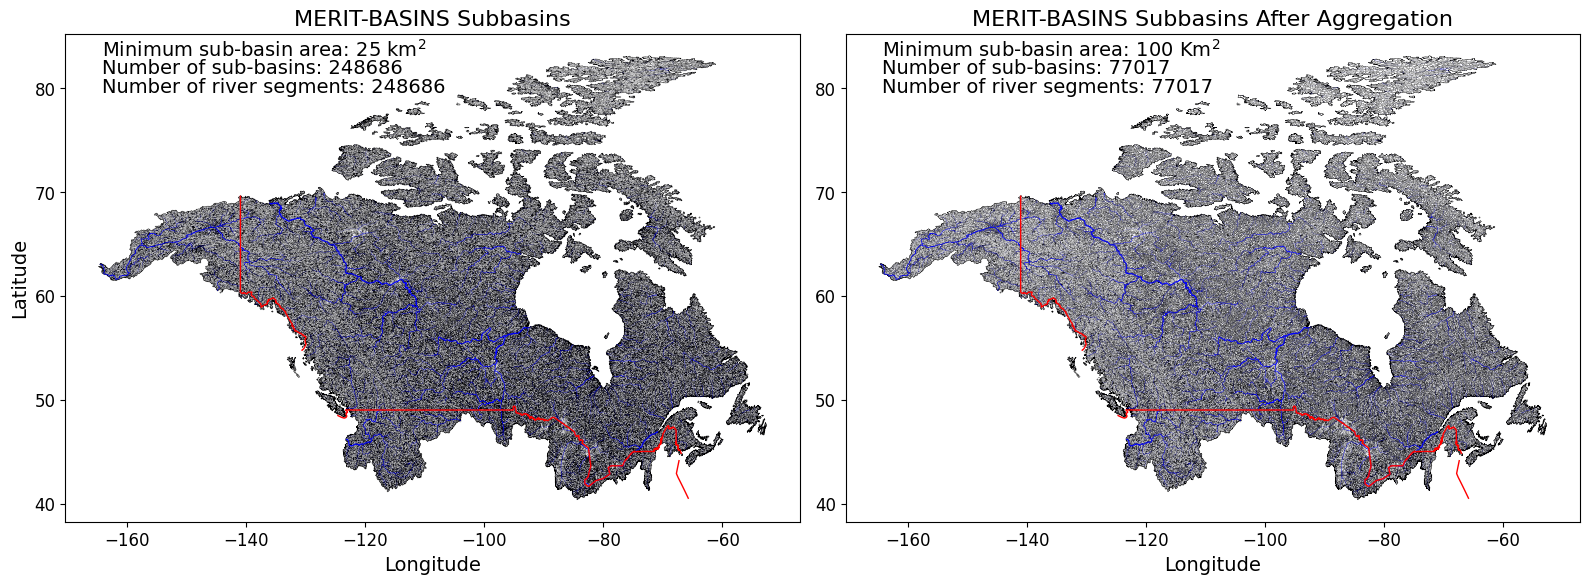

## Ploting MESH_drainage_database.nc inputs

/tmp/ipykernel_32187/2297627020.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap).copy()


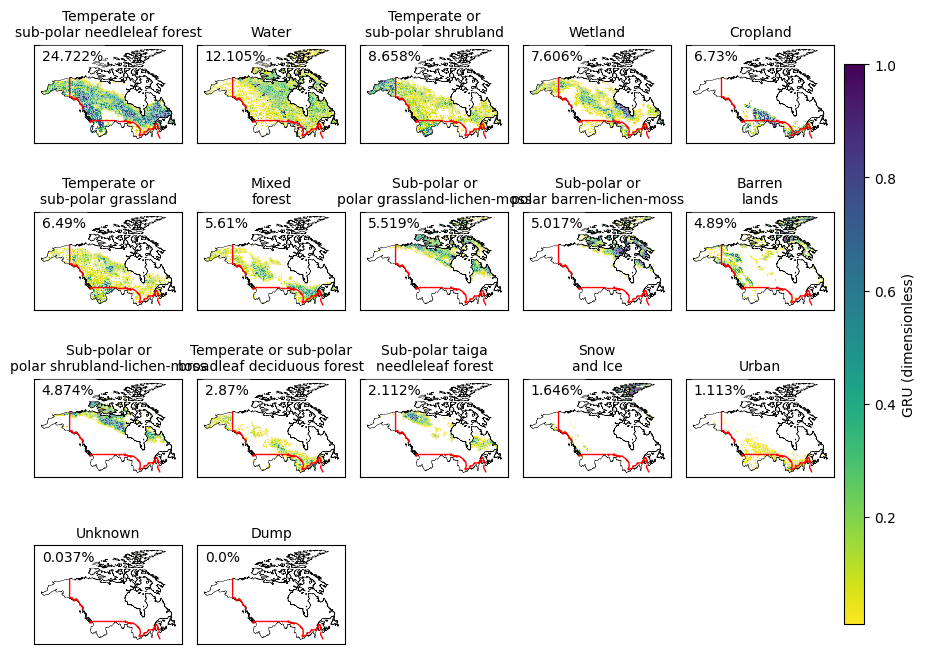

In [38]:
ddbnetcdf_path = os.path.join(base_scratch_dir, 'MESH-CanTrans/MESH_drainage_database_NoPolish.nc')
save_path = os.path.join(base_scratch_dir, 'MESH-CanTrans/GRU_Fraction_NoPolish.png')

variable_name = 'GRU'  # or 'GRU' or any other variable in the file

plt_var_from_vector_ddb_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    ddbnetcdf_path, 
    variable_name, 
    save_path,
    text_location=(0.05, 0.95),
    font_size=10,
    cmap='viridis_r',  # You can specify a different colormap here if needed
    cbar_location=[0.91, 0.15, 0.02, 0.7],  # Custom colorbar location if needed
    subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.1, 'hspace': 0.2}  # Optional subplot adjustments
)


## Ploting MESH_parameters.nc inputs

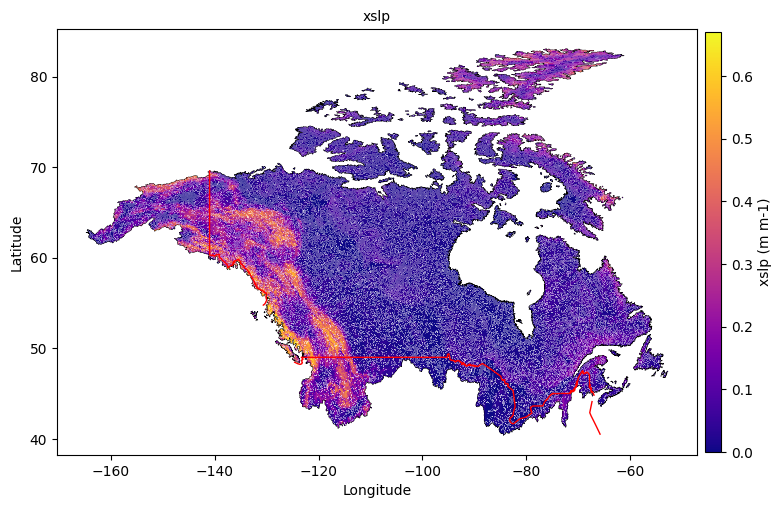

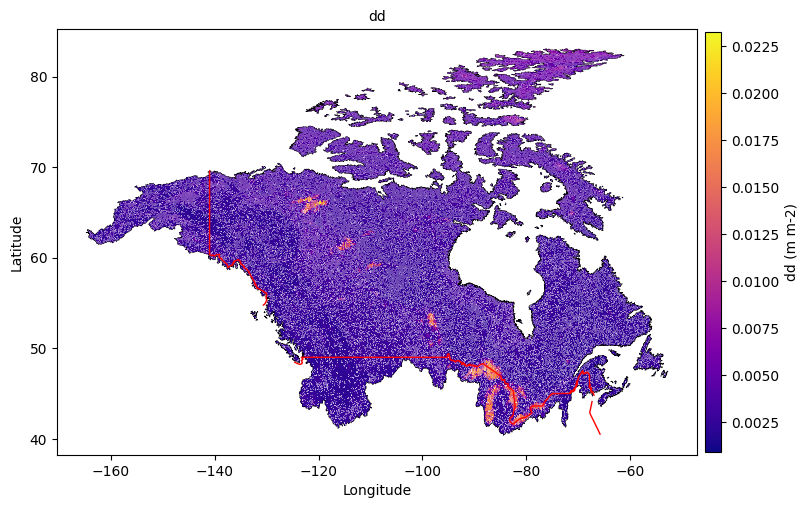

In [36]:
# Read the MESH_parameters.nc file
params_netcdf_path = os.path.join(base_scratch_dir, 'CanTrans_MESH_parameters.nc')

# Average subbasin slope
variable_name = 'xslp'  # or 'SAND', 'ORGM', or any other variable in the NetCDF file
save_path = os.path.join(base_scratch_dir, 'xslp.png')

plt_var_from_vector_params_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    params_netcdf_path, 
    variable_name, 
    save_path,
    text_location=(0.55, 0.95),
    font_size=10,
    cmap='plasma',  # You can change the colormap
    cbar_location=[0.91, 0.15, 0.02, 0.7],  # Customize the colorbar location if needed
    subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.2, 'hspace': 0.2}
)

# Average subbasin drainage density
variable_name = 'dd'  # or 'SAND', 'ORGM', or any other variable in the NetCDF file
save_path = os.path.join(base_scratch_dir, 'dd.png')

plt_var_from_vector_params_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    params_netcdf_path, 
    variable_name, 
    save_path,
    text_location=(0.55, 0.95),
    font_size=10,
    cmap='plasma',  # You can change the colormap
    cbar_location=[0.91, 0.15, 0.02, 0.7],  # Customize the colorbar location if needed
    subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.2, 'hspace': 0.2}
)

/tmp/ipykernel_16011/2879473548.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap).copy()


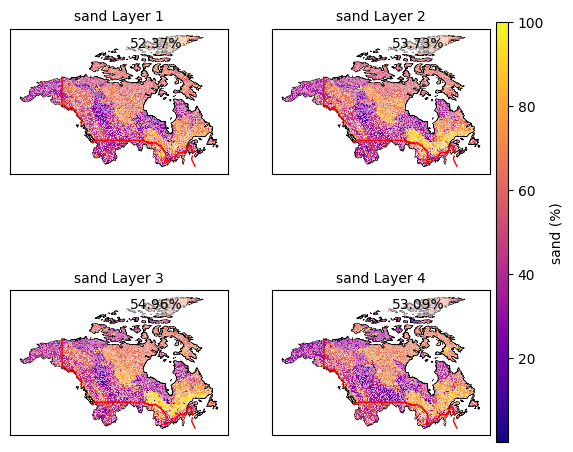

/tmp/ipykernel_16011/2879473548.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap).copy()


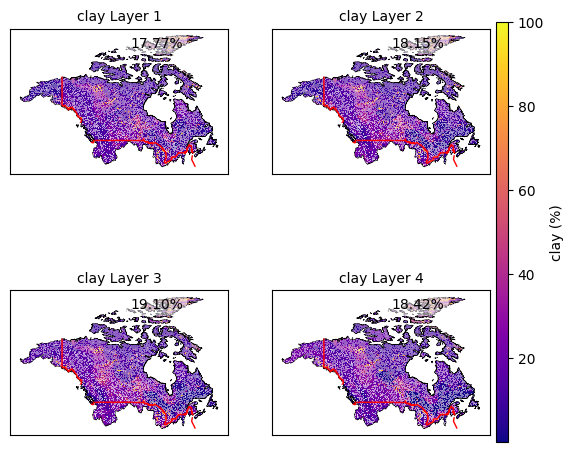

/tmp/ipykernel_16011/2879473548.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap).copy()


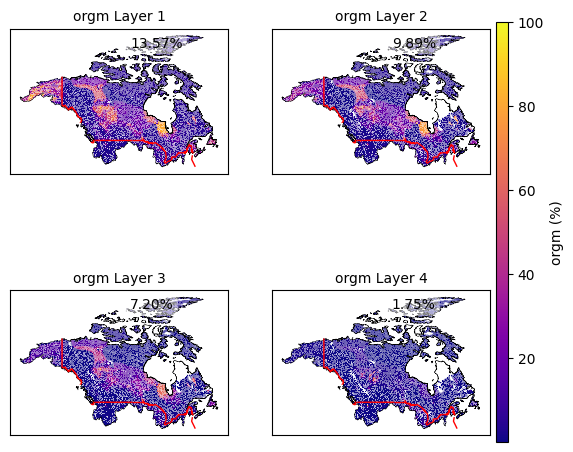

In [14]:
# Read the MESH_parameters.nc file
params_netcdf_path = os.path.join(base_scratch_dir, 'CanTrans_MESH_parameters.nc')

# Average subbasin slope
variable_name = 'sand'  # or 'SAND', 'ORGM', or any other variable in the NetCDF file
save_path = os.path.join(base_scratch_dir, 'sand.png')

plt_var_from_vector_params_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    params_netcdf_path, 
    variable_name, 
    save_path,
    text_location=(0.05, 0.95),
    font_size=10,
    cmap='plasma',  # You can change the colormap
    cbar_location=[0.91, 0.15, 0.02, 0.7],  # Customize the colorbar location if needed
    subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.2, 'hspace': 0.2}
)

# Average subbasin drainage density
variable_name = 'clay'  # or 'SAND', 'ORGM', or any other variable in the NetCDF file
save_path = os.path.join(base_scratch_dir, 'clay.png')

plt_var_from_vector_params_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    params_netcdf_path, 
    variable_name, 
    save_path,
    text_location=(0.05, 0.95),
    font_size=10,
    cmap='plasma',  # You can change the colormap
    cbar_location=[0.91, 0.15, 0.02, 0.7],  # Customize the colorbar location if needed
    subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.2, 'hspace': 0.2}
)

# Average subbasin drainage density
variable_name = 'orgm'  # or 'SAND', 'ORGM', or any other variable in the NetCDF file
save_path = os.path.join(base_scratch_dir, 'orgm.png')

plt_var_from_vector_params_netcdf(
    output_basin_path,
    dissolved_basin_path,
    border_path,
    params_netcdf_path, 
    variable_name, 
    save_path,
    text_location=(0.05, 0.95),
    font_size=10,
    cmap='plasma',  # You can change the colormap
    cbar_location=[0.91, 0.15, 0.02, 0.7],  # Customize the colorbar location if needed
    subplot_adjustments={'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9, 'wspace': 0.2, 'hspace': 0.2}
)